# Tabular Deep Learning (TabM / TabPFN)

Tabular deep learning tests whether a rank-1 adapter ensemble can improve on
linear and tree-based models using the same flat 44-feature matrix. The
19-symbol cross-section makes checkpoint coverage and training reproducibility
especially important because small ranking changes can move the selected model.

**Learning Objectives**:
- Train TabM on walk-forward folds with IC checkpoint evaluation
- Compare TabM configurations (small/medium/large) on the 19-perp universe
- Assess whether rank-1 adapter ensembles capture patterns beyond tree splits
- Generate backtesting-ready predictions from the best configuration

**Book Reference**: Chapter 12, Section 12.3 (Deep Learning Alternatives)

**Prerequisites**: [`03_financial_features`](03_financial_features.ipynb),
[`04_model_based_features`](04_model_based_features.ipynb), and [`07_gbm`](07_gbm.ipynb)

In [1]:
"""Tabular deep-learning grid search through walk-forward cross-validation."""

import warnings

import numpy as np
import plotly.graph_objects as go
import polars as pl
import torch
import yaml
from ml4t.diagnostic.metrics import cross_sectional_ic

import utils.style as style
from case_studies.utils.registry import (
    build_training_spec,
    compute_fold_metrics_from_predictions,
    load_prediction_sets,
    modeling_input_fingerprint,
    read_predictions,
    training_hash_from_spec,
    training_run_status,
)
from case_studies.utils.tabular_dl import run_tabm_cv
from utils.modeling import load_configs, load_modeling_dataset
from utils.paths import get_case_study_dir
from utils.reproducibility import set_global_seeds

warnings.filterwarnings("ignore")

In [2]:
CASE_STUDY_ID = "crypto_perps_funding"
PRIMARY_LABEL = ""  # Read from setup.yaml if empty
MAX_SYMBOLS = 0
FORCE_RETRAIN = False  # Set True to retrain configs that already have complete hashes
PREDICTION_SPLIT = "validation"
N_EPOCHS = 100
BATCH_SIZE = 4096
MAX_FOLDS = 0
TRAIN_DEVICE = "cuda"
SEED = 42

In [3]:
set_global_seeds(SEED)

# Resolve config from setup.yaml
CASE_DIR = get_case_study_dir(CASE_STUDY_ID)
setup = yaml.safe_load((CASE_DIR / "config" / "setup.yaml").read_text())

if not PRIMARY_LABEL:
    PRIMARY_LABEL = setup["labels"]["primary"]
    print(f"Label from setup.yaml: {PRIMARY_LABEL}")
else:
    print(f"Label override: {PRIMARY_LABEL}")

tdl_config = setup.get("modeling", {}).get("tabular_dl", {})
MODELS = tdl_config.get("models", ["tabm"])
include_tabpfn = "tabpfn" in MODELS
if TRAIN_DEVICE not in {"cpu", "cuda"}:
    raise ValueError("TRAIN_DEVICE must be 'cpu' or 'cuda'")
if TRAIN_DEVICE != "cuda":
    raise ValueError("Crypto publication TabM training requires TRAIN_DEVICE='cuda'")
if not torch.cuda.is_available():
    raise RuntimeError("Crypto TabM requires CUDA, but PyTorch cannot see a CUDA device")
device_str = TRAIN_DEVICE
print(f"Case study: {CASE_STUDY_ID}")
print(f"Device: {device_str} | Models: {MODELS}")
print(f"Epochs: {N_EPOCHS} | Batch: {BATCH_SIZE}")

Label from setup.yaml: fwd_ret_8h
Case study: crypto_perps_funding
Device: cuda | Models: ['tabm']
Epochs: 100 | Batch: 4096


## 1. Load Artifacts

Load pre-computed financial features (Ch8), temporal features (Ch9), labels,
and generate CV splits using the shared modeling infrastructure.

In [4]:
mds = load_modeling_dataset(CASE_STUDY_ID, PRIMARY_LABEL, max_symbols=MAX_SYMBOLS)

dataset = mds.dataset
feature_names = mds.feature_names
label_col = mds.label_col
date_col = mds.date_col
entity_col = mds.entity_cols[0] if mds.entity_cols else "symbol"
splits = mds.splits
if MAX_FOLDS:
    splits = splits[:MAX_FOLDS]
n_features = len(feature_names)
INPUT_FINGERPRINT = modeling_input_fingerprint(
    CASE_DIR,
    PRIMARY_LABEL,
    splits,
    feature_names,
    MAX_SYMBOLS,
)
IDENTITY_PARAMS = {
    "device": TRAIN_DEVICE,
    "input_fingerprint": INPUT_FINGERPRINT,
    "max_symbols": MAX_SYMBOLS,
    "max_folds": MAX_FOLDS,
    "batch_size": BATCH_SIZE,
}

print(f"Dataset: {len(dataset):,} rows × {n_features} features")
print(f"Label: {label_col} | Date: {date_col} | Entity: {entity_col}")
print(f"Input lineage: {INPUT_FINGERPRINT[:12]}")
for s in splits:
    print(
        f"  Fold {s['fold']}: train {str(s['train_start'])[:10]}\u2192{str(s['train_end'])[:10]}  "
        f"val {str(s['val_start'])[:10]}\u2192{str(s['val_end'])[:10]}"
    )

Dataset: 100,741 rows × 44 features
Label: fwd_ret_8h | Date: timestamp | Entity: symbol
Input lineage: 962cfd4e882e
  Fold 0: train 2020-12-29→2023-01-01  val 2023-01-02→2023-12-31
  Fold 1: train 2020-01-01→2022-01-02  val 2022-01-03→2023-01-01


## 1b. Data Diagnostics

In [5]:
dataset_pd = dataset.to_pandas()

label_nans = dataset_pd[label_col].isna().sum()
feat_nan_rate = dataset_pd[feature_names].isna().mean().mean()
n_entities = dataset_pd[entity_col].nunique()

print(f"Entities: {n_entities}")
print(f"Label NaN: {label_nans:,} / {len(dataset_pd):,} ({label_nans / len(dataset_pd):.1%})")
print(f"Feature NaN rate: {feat_nan_rate:.1%}")

Entities: 19
Label NaN: 0 / 100,741 (0.0%)
Feature NaN rate: 6.0%


## 2. Build Grid

TabM configurations: small (64h×4m), medium (128h×8m), large (256h×16m).
Optionally includes TabPFN (foundation model, subsampled to 2K training rows).

In [6]:
tabdl_configs = load_configs(CASE_STUDY_ID, PRIMARY_LABEL, "tabular_dl")

# Apply Papermill overrides to configs (test mode: fewer epochs)
for cfg in tabdl_configs:
    if cfg.get("n_epochs", 100) != N_EPOCHS:
        cfg["n_epochs"] = N_EPOCHS
    if cfg.get("batch_size", 4096) != BATCH_SIZE:
        cfg["batch_size"] = BATCH_SIZE

print(f"Grid: {len(tabdl_configs)} configs × {N_EPOCHS} epochs × {len(splits)} folds")
for cfg in tabdl_configs:
    name = cfg["config_name"]
    params = cfg.get("params", {})
    if name.startswith("tabpfn"):
        print(f"  {name:15s}  max_samples={params.get('max_samples', 2000)}")
    else:
        print(
            f"  {name:15s}  hidden={params['hidden_dim']}  "
            f"members={params['n_members']}  dropout={params['dropout']}"
        )

Grid: 3 configs × 100 epochs × 2 folds
  tabm_s           hidden=64  members=4  dropout=0.1
  tabm_m           hidden=128  members=8  dropout=0.1
  tabm_l           hidden=256  members=16  dropout=0.1


## 3. Run Tabular DL CV

Walk-forward training evaluates every epoch checkpoint on decision-time IC.
On a complete content-matched registry, the notebook reads physical prediction files
directly and separates any legacy multi-epoch parquet before scoring. This is
read-only. A fresh output root trains and registers each epoch separately.

Each physical config-epoch prediction set is scored after pooling its walk-forward
folds. This preserves the decision-time weighting required by the case-study contract.

In [7]:
def _checkpoint_metrics(config_name: str, epoch: int, frame: pl.DataFrame) -> dict:
    """Score one physical checkpoint on decision-time rank IC."""
    stats = cross_sectional_ic(
        frame,
        frame,
        pred_col="y_score",
        ret_col="y_true",
        date_col=date_col,
        entity_col=entity_col,
        min_obs=5,
    )
    return {
        "config": config_name,
        "epoch": int(epoch),
        "ic_mean": float(stats["ic_mean"]),
        "ic_std": float(stats["ic_std"]),
        "ic_n_days": int(stats["n_periods"]),
        "n_obs": frame.height,
        "n_null": int(frame["y_score"].null_count() + frame["y_score"].is_nan().sum()),
    }

Checkpoint keys must be unique. Selection then admits only finite, null-free
checkpoints that cover the maximum number of validation timestamps.

In [8]:
def _checkpoint_curves(all_predictions: pl.DataFrame) -> pl.DataFrame:
    """Build the complete-coverage checkpoint comparison."""
    required = {date_col, entity_col, "fold_id", "config", "epoch", "y_true", "y_score"}
    missing = required - set(all_predictions.columns)
    if missing:
        raise ValueError(f"Prediction frame is missing columns: {sorted(missing)}")

    key_cols = [date_col, entity_col, "fold_id", "config", "epoch"]
    if all_predictions.select(key_cols).is_duplicated().any():
        raise ValueError("Duplicate config-checkpoint prediction keys")

    curves = [
        _checkpoint_metrics(config_name, epoch, frame)
        for (config_name, epoch), frame in all_predictions.partition_by(
            ["config", "epoch"], as_dict=True, maintain_order=True
        ).items()
    ]
    curve_frame = pl.DataFrame(curves)
    full_days = int(curve_frame["ic_n_days"].max())
    return curve_frame.with_columns(
        (
            (pl.col("ic_n_days") == full_days)
            & (pl.col("n_null") == 0)
            & pl.col("ic_mean").is_finite()
        ).alias("selectable")
    )

Within each architecture, the best eligible epoch represents that configuration.
A shorter vintage remains visible but cannot enter the cross-config ranking.

In [9]:
def _grid_summary(curve_frame: pl.DataFrame) -> list[dict]:
    """Summarize the best eligible checkpoint for each configuration."""
    grid = []
    for config_name in curve_frame["config"].unique(maintain_order=True):
        config_curves = curve_frame.filter(pl.col("config") == config_name)
        config_selectable = config_curves.filter("selectable")
        ranked = config_selectable if not config_selectable.is_empty() else config_curves
        top = ranked.sort("ic_mean", descending=True).row(0, named=True)
        grid.append(
            {
                "config_name": config_name,
                "best_epoch": int(top["epoch"]),
                "best_ic": float(top["ic_mean"]),
                "ic_n_days": int(top["ic_n_days"]),
                "n_null": int(top["n_null"]),
                "selectable": bool(top["selectable"]),
                "elapsed_s": 0.0,
            }
        )
    return sorted(grid, key=lambda row: row["best_ic"], reverse=True)

The final result exposes the selected checkpoint, its fold diagnostics, and the
full physical curve so every displayed claim traces to one prediction artifact.

In [10]:
def _canonical_result(all_predictions: pl.DataFrame) -> dict:
    """Select checkpoints by pooled decision-time IC and complete coverage."""
    curves = _checkpoint_curves(all_predictions)
    grid = _grid_summary(curves)
    eligible = [row for row in grid if row["selectable"]]
    if not eligible:
        raise RuntimeError("No complete TabM checkpoint is selectable")
    best = max(eligible, key=lambda row: row["best_ic"])
    predictions = all_predictions.filter(
        (pl.col("config") == best["config_name"]) & (pl.col("epoch") == best["best_epoch"])
    )
    return {
        "grid_results": grid,
        "best_config_name": best["config_name"],
        "best_epoch": best["best_epoch"],
        "best_ic": best["best_ic"],
        "predictions": predictions,
        "all_predictions": all_predictions,
        "fold_metrics": compute_fold_metrics_from_predictions(
            all_predictions, best["config_name"], best["best_epoch"], date_col=date_col
        ),
        "all_learning_curves": curves,
        "training_log": pl.DataFrame(),
        "full_days": int(curves["ic_n_days"].max()),
    }

Legacy registry rows may point to a parquet that contains several physical epochs.
Normalization retains the internal config and epoch before applying the reader limit.

In [11]:
def _normalize_prediction_frame(
    config: dict, prediction_set: dict, frame: pl.DataFrame
) -> tuple[pl.DataFrame, str | None]:
    """Normalize one physical prediction file without collapsing checkpoints."""
    if "config" not in frame.columns:
        frame = frame.with_columns(pl.lit(config["config_name"]).alias("config"))
    if "epoch" not in frame.columns:
        checkpoint = prediction_set["checkpoint_value"]
        if checkpoint is None:
            raise ValueError(f"Missing physical epoch for {config['config_name']}")
        frame = frame.with_columns(pl.lit(int(checkpoint)).alias("epoch"))

    physical_epochs = sorted(frame["epoch"].unique().to_list())
    anomaly = None
    if len(physical_epochs) > 1:
        anomaly = f"{config['config_name']}: registry row contains epochs {physical_epochs}"
    normalized = frame.filter(
        (pl.col("config") == config["config_name"]) & (pl.col("epoch") <= N_EPOCHS)
    ).select(
        date_col,
        entity_col,
        "fold_id",
        "y_score",
        "y_true",
        "config",
        "epoch",
    )
    return normalized, anomaly

Prediction hashes are de-duplicated before physical files are loaded. Missing
registered validation predictions are a hard failure, not an implicit retrain.

In [12]:
def _load_config_predictions(config: dict) -> tuple[list[pl.DataFrame], list[str]]:
    """Load every distinct physical prediction file for one configuration."""
    spec = build_training_spec(
        config["family"],
        config["config_name"],
        label_col,
        n_folds=len(splits),
        n_epochs=config.get("n_epochs"),
        extra_params=IDENTITY_PARAMS,
    )
    sets = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=training_hash_from_spec(spec),
        split=PREDICTION_SPLIT,
    )
    if sets.is_empty():
        raise FileNotFoundError(f"Missing current predictions for {config['config_name']}")

    frames, anomalies, seen_hashes = [], [], set()
    for prediction_set in sets.iter_rows(named=True):
        prediction_hash = prediction_set["prediction_hash"]
        if prediction_hash in seen_hashes:
            continue
        seen_hashes.add(prediction_hash)
        frame = read_predictions(CASE_STUDY_ID, prediction_hash)
        normalized, anomaly = _normalize_prediction_frame(config, prediction_set, frame)
        frames.append(normalized)
        if anomaly:
            anomalies.append(anomaly)
    return frames, anomalies

The cached path concatenates physical files only after each one has preserved its
own epoch identity. This prevents a combined-file metric from entering selection.

In [13]:
def _load_registered_predictions() -> tuple[pl.DataFrame, list[str]]:
    """Read content-matched physical files without collapsing their epochs."""
    frames, anomalies = [], []
    for config in tabdl_configs:
        config_frames, config_anomalies = _load_config_predictions(config)
        frames.extend(config_frames)
        anomalies.extend(config_anomalies)
    return pl.concat(frames), anomalies

A configuration is cached only when both its training state and validation
prediction set are complete. Otherwise the fresh CUDA path trains the full grid.

In [14]:
def _config_is_cached(config: dict) -> bool:
    """Check whether one configuration has complete current validation output."""
    spec = build_training_spec(
        config["family"],
        config["config_name"],
        label_col,
        n_folds=len(splits),
        n_epochs=config.get("n_epochs"),
        extra_params=IDENTITY_PARAMS,
    )
    sets = load_prediction_sets(
        CASE_STUDY_ID,
        training_hash=training_hash_from_spec(spec),
        split=PREDICTION_SPLIT,
    )
    return training_run_status(CASE_STUDY_ID, spec).complete and not sets.is_empty()

Fresh execution delegates model fitting to the shared runner. If its final summary
fails after epoch registration, the narrow recovery path reads those physical files.

In [15]:
def _train_current_predictions() -> pl.DataFrame:
    """Train the current CUDA grid and return every registered checkpoint."""
    try:
        raw_result = run_tabm_cv(
            dataset_pd,
            splits,
            feature_names=feature_names,
            label_col=label_col,
            date_col=date_col,
            entity_col=entity_col,
            configs=tabdl_configs,
            n_features=n_features,
            device=device_str,
            save_dir=CASE_DIR / "run_log" / "training" / "tabular_dl",
            register=True,
            force_retrain=FORCE_RETRAIN,
            prediction_split=PREDICTION_SPLIT,
            case_study=CASE_STUDY_ID,
            notebook="08_tabular_dl",
            temporal_by_fold=mds.temporal_by_fold,
            temporal_keys=mds.temporal_keys,
            temporal_feature_names=mds.temporal_feature_names,
            identity_params=IDENTITY_PARAMS,
        )
        return raw_result["all_predictions"]
    except UnboundLocalError as exc:
        if "compute_fold_metrics_from_predictions" not in str(exc):
            raise
        current_predictions, recovery_anomalies = _load_registered_predictions()
        if recovery_anomalies:
            raise RuntimeError(
                "Fresh epoch registration produced a multi-epoch prediction file"
            ) from exc
        return current_predictions

Production execution is read-only when the entire grid is cached. In a fresh
output root, the same cells train on CUDA and canonicalize every registered epoch.

In [16]:
_cache_complete = not FORCE_RETRAIN and all(_config_is_cached(cfg) for cfg in tabdl_configs)

if _cache_complete:
    _registered_predictions, _registered_anomalies = _load_registered_predictions()
    print("Current registry is complete; reconstructing physical checkpoints read-only.")
    for _anomaly in _registered_anomalies:
        print(f"  legacy artifact: {_anomaly}")
    result = _canonical_result(_registered_predictions)
    cached_mode = True
else:
    result = _canonical_result(_train_current_predictions())
    cached_mode = False

Current registry is complete; reconstructing physical checkpoints read-only.


## 4. Grid Results

In [17]:
grid_results = result["grid_results"]
best_name = result["best_config_name"]
best_epoch = result["best_epoch"]
best_ic = result["best_ic"]

print(f"Selected: {best_name} at epoch {best_epoch}, IC={best_ic:+.4f}")
for row in grid_results:
    if not row["selectable"]:
        print(
            f"Excluded partial vintage: {row['config_name']} at epoch {row['best_epoch']}, "
            f"IC={row['best_ic']:+.4f} over {row['ic_n_days']:,} dates"
        )

Selected: tabm_s at epoch 50, IC=+0.0151


The complete-coverage guard prevents a shorter checkpoint history from winning
through missing periods. The current content hash binds this comparison to the
corrected 44-feature lineage and CUDA execution contract.

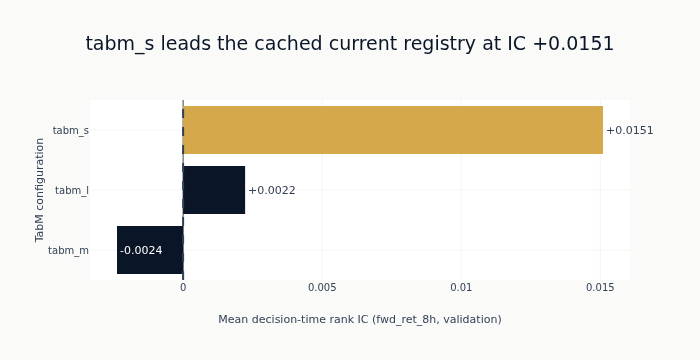

In [18]:
_selectable_grid = [row for row in grid_results if row["selectable"]]
if _selectable_grid:
    _ranked_grid = sorted(_selectable_grid, key=lambda row: row["best_ic"])
    grid_figure = go.Figure(
        go.Bar(
            x=[row["best_ic"] for row in _ranked_grid],
            y=[row["config_name"] for row in _ranked_grid],
            orientation="h",
            marker_color=[
                style.COLORS["amber"] if row["config_name"] == best_name else style.COLORS["blue"]
                for row in _ranked_grid
            ],
            text=[f"{row['best_ic']:+.4f}" for row in _ranked_grid],
            textposition=["inside" if row["best_ic"] < 0 else "outside" for row in _ranked_grid],
            insidetextfont=dict(color="white"),
            cliponaxis=False,
        )
    )
    grid_figure.add_vline(x=0.0, line=dict(color=style.COLORS["neutral"], dash="dash"))
    _lineage_label = "cached current registry" if cached_mode else "current CUDA run"
    grid_figure.update_layout(
        template="ml4t",
        title=f"{best_name} leads the {_lineage_label} at IC {best_ic:+.4f}",
        xaxis_title=f"Mean decision-time rank IC ({label_col}, validation)",
        yaxis_title="TabM configuration",
        height=360,
        margin=dict(l=90, r=70),
        showlegend=False,
    )
    grid_figure.show()

## 5. Checkpoint Curves

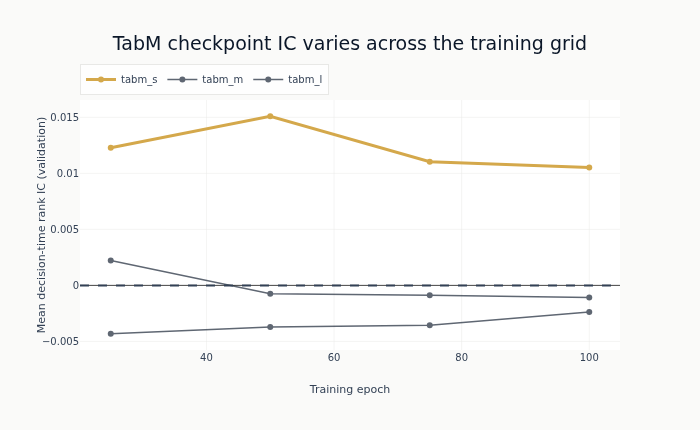

In [19]:
curves = result["all_learning_curves"]
if curves.height > 0:
    curve_figure = go.Figure()
    _selectable_by_config = {row["config_name"]: row["selectable"] for row in grid_results}
    for config_name in curves["config"].unique(maintain_order=True):
        config_curve = curves.filter(pl.col("config") == config_name).sort("epoch")
        is_leader = config_name == best_name
        is_selectable = _selectable_by_config[config_name]
        curve_figure.add_trace(
            go.Scatter(
                x=config_curve["epoch"].to_list(),
                y=config_curve["ic_mean"].to_list(),
                mode="lines+markers",
                name=config_name if is_selectable else f"{config_name} (partial vintage)",
                line=dict(
                    color=style.COLORS["amber"] if is_leader else style.COLORS["blue"],
                    width=3 if is_leader else 1.5,
                    dash="solid" if is_selectable else "dash",
                ),
                opacity=1.0 if is_leader else 0.65,
            )
        )
    curve_figure.add_hline(y=0.0, line=dict(color=style.COLORS["neutral"], dash="dash"))
    curve_figure.update_layout(
        template="ml4t",
        title="TabM checkpoint IC varies across the training grid",
        xaxis_title="Training epoch",
        yaxis_title="Mean decision-time rank IC (validation)",
        height=430,
        legend=dict(orientation="h", yanchor="bottom", y=1.02, x=0),
    )
    curve_figure.show()

## 6. Fold Metrics

In [20]:
fold_metrics = result["fold_metrics"]
if fold_metrics.height > 0:
    print(f"\nPer-fold IC ({best_name}):")
    for row in fold_metrics.iter_rows(named=True):
        print(f"  Fold {row['fold_id']}: IC={row['ic_mean']:+.4f}  n_test={row['n_test']:,}")
    mean_ic = fold_metrics["ic_mean"].mean()
    print(f"\n  Mean IC: {mean_ic:+.4f}")


Per-fold IC (tabm_s):
  Fold 0: IC=+0.0127  n_test=18,675
  Fold 1: IC=+0.0175  n_test=16,733

  Mean IC: +0.0151


## 7. Result Disposition

The default cached path performs no writes. A fresh output-root run registers
each physical epoch separately during training.

In [21]:
predictions = result["predictions"]
all_predictions = result["all_predictions"]

print(f"Selected predictions: {predictions.height:,} rows")
print(f"All physical checkpoint predictions: {all_predictions.height:,} rows")
if curves.height > 0:
    print(f"learning_curves.parquet: {curves.height:,} rows")
if fold_metrics.height > 0:
    print(f"fold_metrics.parquet: {fold_metrics.height} rows")

Selected predictions: 35,408 rows
All physical checkpoint predictions: 424,896 rows
learning_curves.parquet: 12 rows
fold_metrics.parquet: 2 rows


## 8. Key Takeaways

The current CUDA surface compares all three TabM architectures on the same
corrected folds and complete checkpoint coverage. Architecture size does not
guarantee a stable ordering across training duration. With only 19 symbols,
validation coverage and checkpoint accounting remain more consequential than
small headline differences.

**Next**: [`09_dl_lstm`](09_dl_lstm.ipynb) tests whether LSTM's sequential memory captures
funding rate regime dynamics that flat-feature models miss.
**Book**: Chapter 12.3 discusses when tabular DL achieves higher IC than GBMs.